In [19]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from math import radians, sin, cos, sqrt, atan2

warnings.filterwarnings("ignore")

In [20]:
# =========================
# Paths
# =========================
INPUT_PATH = "Dataset/Processed/cleaned_crime.csv"

OUTPUT_DIR = "Outputs/multi_year"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# =========================
# Parameters
# =========================
START_YEAR = 2018
END_YEAR = 2025

EPS_METERS = 300
MIN_SAMPLES = 50
MATCH_THRESHOLD_KM = 1.5
EARTH_RADIUS_KM = 6371.0088

# DBSCAN with haversine needs radians and epsilon in radians
EPS_RAD = EPS_METERS / 1000.0 / EARTH_RADIUS_KM

In [21]:
df = pd.read_csv(INPUT_PATH)

print("Shape before processing:", df.shape)
print(df.head())

Shape before processing: (8381931, 5)
                  Date     Primary Type   Latitude  Longitude  Year
0  2020-08-10 09:45:00          ROBBERY  41.908418 -87.677407  2020
1  2023-09-06 17:00:00  CRIMINAL DAMAGE  41.886018 -87.633938  2023
2  2023-09-06 11:00:00            THEFT  41.871835 -87.626151  2023
3  2019-05-21 08:20:00         BURGLARY  41.856547 -87.695605  2019
4  2021-07-07 10:30:00      SEX OFFENSE  41.655116 -87.594883  2021


In [22]:
# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop missing required fields
df = df.dropna(subset=["Date", "Latitude", "Longitude"]).copy()

# Extract Year and Quarter
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

# Keep only needed years
df = df[(df["Year"] >= START_YEAR) & (df["Year"] <= END_YEAR)].copy()

print("Shape after filtering:", df.shape)
print("Years included:", sorted(df["Year"].unique()))

Shape after filtering: (1922556, 6)
Years included: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [23]:
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Compute haversine distance in kilometers between two lat/lon points.
    """
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return EARTH_RADIUS_KM * c

In [24]:
def run_dbscan_quarter(quarter_df, eps_rad=EPS_RAD, min_samples=MIN_SAMPLES):
    """
    Run DBSCAN with haversine distance on one quarter of data.
    Returns clustered dataframe, cluster summary, and centroids.
    """
    quarter_df = quarter_df.copy()

    if quarter_df.empty:
        return quarter_df, 0, 0.0, pd.DataFrame(columns=["Cluster", "Centroid_Lat", "Centroid_Lon", "Size"])

    coords_deg = quarter_df[["Latitude", "Longitude"]].to_numpy()
    coords_rad = np.radians(coords_deg)

    model = DBSCAN(
        eps=eps_rad,
        min_samples=min_samples,
        metric="haversine",
        algorithm="ball_tree"
    )

    labels = model.fit_predict(coords_rad)
    quarter_df["Cluster"] = labels

    total_points = len(quarter_df)
    noise_points = np.sum(labels == -1)
    noise_pct = (noise_points / total_points) * 100 if total_points > 0 else 0

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    clustered_only = quarter_df[quarter_df["Cluster"] != -1].copy()

    if clustered_only.empty:
        centroids = pd.DataFrame(columns=["Cluster", "Centroid_Lat", "Centroid_Lon", "Size"])
    else:
        centroids = (
            clustered_only
            .groupby("Cluster")
            .agg(
                Centroid_Lat=("Latitude", "mean"),
                Centroid_Lon=("Longitude", "mean"),
                Size=("Cluster", "size")
            )
            .reset_index()
        )

    return quarter_df, n_clusters, noise_pct, centroids

In [25]:
def match_centroids(prev_centroids, curr_centroids, threshold_km=MATCH_THRESHOLD_KM):
    """
    Match cluster centroids between consecutive quarters.

    Returns:
    - matches_df
    - persisted_count
    - disappeared_count
    - emerged_count
    - persistence_rate
    """
    if prev_centroids.empty and curr_centroids.empty:
        matches_df = pd.DataFrame(columns=[
            "Prev_Cluster", "Curr_Cluster", "Distance_km", "Status"
        ])
        return matches_df, 0, 0, 0, 0.0

    if prev_centroids.empty:
        matches_df = curr_centroids[["Cluster"]].copy()
        matches_df["Prev_Cluster"] = np.nan
        matches_df["Curr_Cluster"] = matches_df["Cluster"]
        matches_df["Distance_km"] = np.nan
        matches_df["Status"] = "emerged"
        matches_df = matches_df[["Prev_Cluster", "Curr_Cluster", "Distance_km", "Status"]]
        return matches_df, 0, 0, len(curr_centroids), 0.0

    if curr_centroids.empty:
        matches_df = prev_centroids[["Cluster"]].copy()
        matches_df["Prev_Cluster"] = matches_df["Cluster"]
        matches_df["Curr_Cluster"] = np.nan
        matches_df["Distance_km"] = np.nan
        matches_df["Status"] = "disappeared"
        matches_df = matches_df[["Prev_Cluster", "Curr_Cluster", "Distance_km", "Status"]]
        return matches_df, 0, len(prev_centroids), 0, 0.0

    used_prev = set()
    used_curr = set()
    match_rows = []

    for _, curr_row in curr_centroids.iterrows():
        curr_cluster = curr_row["Cluster"]
        curr_lat = curr_row["Centroid_Lat"]
        curr_lon = curr_row["Centroid_Lon"]

        best_prev = None
        best_dist = float("inf")

        for _, prev_row in prev_centroids.iterrows():
            prev_cluster = prev_row["Cluster"]

            if prev_cluster in used_prev:
                continue

            prev_lat = prev_row["Centroid_Lat"]
            prev_lon = prev_row["Centroid_Lon"]

            dist_km = haversine_km(prev_lat, prev_lon, curr_lat, curr_lon)

            if dist_km < best_dist:
                best_dist = dist_km
                best_prev = prev_cluster

        if best_prev is not None and best_dist <= threshold_km:
            used_prev.add(best_prev)
            used_curr.add(curr_cluster)

            match_rows.append({
                "Prev_Cluster": best_prev,
                "Curr_Cluster": curr_cluster,
                "Distance_km": best_dist,
                "Status": "persisted"
            })

    # Disappeared
    for _, prev_row in prev_centroids.iterrows():
        prev_cluster = prev_row["Cluster"]
        if prev_cluster not in used_prev:
            match_rows.append({
                "Prev_Cluster": prev_cluster,
                "Curr_Cluster": np.nan,
                "Distance_km": np.nan,
                "Status": "disappeared"
            })

    # Emerged
    for _, curr_row in curr_centroids.iterrows():
        curr_cluster = curr_row["Cluster"]
        if curr_cluster not in used_curr:
            match_rows.append({
                "Prev_Cluster": np.nan,
                "Curr_Cluster": curr_cluster,
                "Distance_km": np.nan,
                "Status": "emerged"
            })

    matches_df = pd.DataFrame(match_rows)

    persisted_count = (matches_df["Status"] == "persisted").sum()
    disappeared_count = (matches_df["Status"] == "disappeared").sum()
    emerged_count = (matches_df["Status"] == "emerged").sum()

    persistence_rate = (
        persisted_count / len(prev_centroids) * 100
        if len(prev_centroids) > 0 else 0.0
    )

    return matches_df, persisted_count, disappeared_count, emerged_count, persistence_rate

In [26]:
quarterly_summary_rows = []
persistence_summary_rows = []
all_matches_rows = []
all_centroids_rows = []

years = list(range(START_YEAR, END_YEAR + 1))

for year in years:
    print(f"\nProcessing year: {year}")

    year_df = df[df["Year"] == year].copy()

    # Fixed quarter order
    quarter_labels = [f"{year}Q1", f"{year}Q2", f"{year}Q3", f"{year}Q4"]

    quarter_centroids = {}
    quarter_clustered_data = {}

    # ---- Run DBSCAN for each quarter ----
    for q in quarter_labels:
        q_df = year_df[year_df["Quarter"] == q].copy()

        clustered_q_df, n_clusters, noise_pct, centroids = run_dbscan_quarter(q_df)

        quarter_clustered_data[q] = clustered_q_df
        quarter_centroids[q] = centroids

        quarterly_summary_rows.append({
            "Year": year,
            "Quarter": q,
            "Records": len(q_df),
            "Clusters": n_clusters,
            "Noise_Percentage": round(noise_pct, 2)
        })

        if not centroids.empty:
            temp_centroids = centroids.copy()
            temp_centroids["Year"] = year
            temp_centroids["Quarter"] = q
            all_centroids_rows.append(temp_centroids)

        print(f"{q}: records={len(q_df)}, clusters={n_clusters}, noise={noise_pct:.2f}%")

    # ---- Match consecutive quarters ----
    for i in range(len(quarter_labels) - 1):
        prev_q = quarter_labels[i]
        curr_q = quarter_labels[i + 1]

        prev_centroids = quarter_centroids[prev_q]
        curr_centroids = quarter_centroids[curr_q]

        matches_df, persisted_count, disappeared_count, emerged_count, persistence_rate = match_centroids(
            prev_centroids,
            curr_centroids,
            threshold_km=MATCH_THRESHOLD_KM
        )

        persistence_summary_rows.append({
            "Year": year,
            "From_Quarter": prev_q,
            "To_Quarter": curr_q,
            "Prev_Clusters": len(prev_centroids),
            "Curr_Clusters": len(curr_centroids),
            "Persisted": persisted_count,
            "Disappeared": disappeared_count,
            "Emerged": emerged_count,
            "Persistence_Rate": round(persistence_rate, 2)
        })

        if not matches_df.empty:
            temp_matches = matches_df.copy()
            temp_matches["Year"] = year
            temp_matches["From_Quarter"] = prev_q
            temp_matches["To_Quarter"] = curr_q
            all_matches_rows.append(temp_matches)

        print(
            f"{prev_q} -> {curr_q}: "
            f"persisted={persisted_count}, "
            f"disappeared={disappeared_count}, "
            f"emerged={emerged_count}, "
            f"persistence={persistence_rate:.2f}%"
        )


Processing year: 2018
2018Q1: records=58434, clusters=84, noise=27.73%
2018Q2: records=69304, clusters=77, noise=21.07%
2018Q3: records=72361, clusters=75, noise=19.72%
2018Q4: records=63424, clusters=72, noise=24.38%
2018Q1 -> 2018Q2: persisted=60, disappeared=24, emerged=17, persistence=71.43%
2018Q2 -> 2018Q3: persisted=59, disappeared=18, emerged=16, persistence=76.62%
2018Q3 -> 2018Q4: persisted=53, disappeared=22, emerged=19, persistence=70.67%

Processing year: 2019
2019Q1: records=58161, clusters=67, noise=28.70%
2019Q2: records=67926, clusters=76, noise=20.72%
2019Q3: records=71230, clusters=71, noise=19.32%
2019Q4: records=61853, clusters=78, noise=24.23%
2019Q1 -> 2019Q2: persisted=47, disappeared=20, emerged=29, persistence=70.15%
2019Q2 -> 2019Q3: persisted=58, disappeared=18, emerged=13, persistence=76.32%
2019Q3 -> 2019Q4: persisted=56, disappeared=15, emerged=22, persistence=78.87%

Processing year: 2020
2020Q1: records=54199, clusters=73, noise=30.80%
2020Q2: records=

In [27]:
quarterly_summary_df = pd.DataFrame(quarterly_summary_rows)
persistence_summary_df = pd.DataFrame(persistence_summary_rows)

all_matches_df = pd.concat(all_matches_rows, ignore_index=True) if all_matches_rows else pd.DataFrame()
all_centroids_df = pd.concat(all_centroids_rows, ignore_index=True) if all_centroids_rows else pd.DataFrame()

print("\nQuarterly Summary:")
print(quarterly_summary_df.head())

print("\nPersistence Summary:")
print(persistence_summary_df.head())


Quarterly Summary:
   Year Quarter  Records  Clusters  Noise_Percentage
0  2018  2018Q1    58434        84             27.73
1  2018  2018Q2    69304        77             21.07
2  2018  2018Q3    72361        75             19.72
3  2018  2018Q4    63424        72             24.38
4  2019  2019Q1    58161        67             28.70

Persistence Summary:
   Year From_Quarter To_Quarter  Prev_Clusters  Curr_Clusters  Persisted  \
0  2018       2018Q1     2018Q2             84             77         60   
1  2018       2018Q2     2018Q3             77             75         59   
2  2018       2018Q3     2018Q4             75             72         53   
3  2019       2019Q1     2019Q2             67             76         47   
4  2019       2019Q2     2019Q3             76             71         58   

   Disappeared  Emerged  Persistence_Rate  
0           24       17             71.43  
1           18       16             76.62  
2           22       19             70.67  
3      

In [28]:
# ============================================
# Create Power BI map file for hotspot evolution
# ============================================

TABLE_DIR = "Outputs/Tables"
os.makedirs(TABLE_DIR, exist_ok=True)

# Safety check
print("all_matches_df shape:", all_matches_df.shape)
print("all_centroids_df shape:", all_centroids_df.shape)

# Split match records by status
persisted_df = all_matches_df[all_matches_df["Status"] == "persisted"].copy()
emerged_df = all_matches_df[all_matches_df["Status"] == "emerged"].copy()
disappeared_df = all_matches_df[all_matches_df["Status"] == "disappeared"].copy()

# -------------------------------
# 1. Persisted hotspots
# Use CURRENT quarter centroid
# because persisted hotspot continues into next quarter
# -------------------------------
persisted_map = persisted_df.merge(
    all_centroids_df,
    left_on=["Year", "To_Quarter", "Curr_Cluster"],
    right_on=["Year", "Quarter", "Cluster"],
    how="left"
)

persisted_map = persisted_map[[
    "Year", "From_Quarter", "To_Quarter", "Status",
    "Prev_Cluster", "Curr_Cluster",
    "Centroid_Lat", "Centroid_Lon", "Size", "Distance_km"
]].copy()

# -------------------------------
# 2. Emerged hotspots
# Use CURRENT quarter centroid
# because hotspot appears in next quarter
# -------------------------------
emerged_map = emerged_df.merge(
    all_centroids_df,
    left_on=["Year", "To_Quarter", "Curr_Cluster"],
    right_on=["Year", "Quarter", "Cluster"],
    how="left"
)

emerged_map = emerged_map[[
    "Year", "From_Quarter", "To_Quarter", "Status",
    "Prev_Cluster", "Curr_Cluster",
    "Centroid_Lat", "Centroid_Lon", "Size", "Distance_km"
]].copy()

# -------------------------------
# 3. Disappeared hotspots
# Use PREVIOUS quarter centroid
# because hotspot existed in previous quarter and then vanished
# -------------------------------
disappeared_map = disappeared_df.merge(
    all_centroids_df,
    left_on=["Year", "From_Quarter", "Prev_Cluster"],
    right_on=["Year", "Quarter", "Cluster"],
    how="left"
)

disappeared_map = disappeared_map[[
    "Year", "From_Quarter", "To_Quarter", "Status",
    "Prev_Cluster", "Curr_Cluster",
    "Centroid_Lat", "Centroid_Lon", "Size", "Distance_km"
]].copy()

# -------------------------------
# Combine all map rows
# -------------------------------
hotspot_evolution_map_df = pd.concat(
    [persisted_map, emerged_map, disappeared_map],
    ignore_index=True
)

# Rename for Power BI
hotspot_evolution_map_df = hotspot_evolution_map_df.rename(columns={
    "Centroid_Lat": "Latitude",
    "Centroid_Lon": "Longitude",
    "Size": "Cluster_Size"
})

# Optional: add simplified transition label
hotspot_evolution_map_df["Transition"] = (
    hotspot_evolution_map_df["From_Quarter"].astype(str)
    + " -> " +
    hotspot_evolution_map_df["To_Quarter"].astype(str)
)

# Reorder columns
hotspot_evolution_map_df = hotspot_evolution_map_df[[
    "Year",
    "From_Quarter",
    "To_Quarter",
    "Transition",
    "Status",
    "Prev_Cluster",
    "Curr_Cluster",
    "Latitude",
    "Longitude",
    "Cluster_Size",
    "Distance_km"
]]

# Save final CSV
map_output_path = os.path.join(TABLE_DIR, "hotspot_evolution_map_2018_2025.csv")
hotspot_evolution_map_df.to_csv(map_output_path, index=False)

print("Saved:", map_output_path)
print(hotspot_evolution_map_df.head())
print(hotspot_evolution_map_df["Status"].value_counts(dropna=False))

all_matches_df shape: (2401, 7)
all_centroids_df shape: (2514, 6)
Saved: Outputs/Tables\hotspot_evolution_map_2018_2025.csv
   Year From_Quarter To_Quarter        Transition     Status  Prev_Cluster  \
0  2018       2018Q1     2018Q2  2018Q1 -> 2018Q2  persisted           4.0   
1  2018       2018Q1     2018Q2  2018Q1 -> 2018Q2  persisted           1.0   
2  2018       2018Q1     2018Q2  2018Q1 -> 2018Q2  persisted          22.0   
3  2018       2018Q1     2018Q2  2018Q1 -> 2018Q2  persisted          30.0   
4  2018       2018Q1     2018Q2  2018Q1 -> 2018Q2  persisted           0.0   

   Curr_Cluster   Latitude  Longitude  Cluster_Size  Distance_km  
0           0.0  41.764992 -87.650351         10552     0.759510  
1           1.0  41.756008 -87.569336          3406     0.351336  
2           2.0  41.691983 -87.625187          1999     0.738974  
3           3.0  42.000794 -87.669388            98     0.565830  
4           4.0  41.879428 -87.727237         12863     0.142460  
Statu

In [29]:
yearly_clusters = (
    quarterly_summary_df
    .groupby("Year", as_index=False)
    .agg(
        Avg_Clusters=("Clusters", "mean"),
        Avg_Noise_Percentage=("Noise_Percentage", "mean")
    )
)

yearly_persistence = (
    persistence_summary_df
    .groupby("Year", as_index=False)
    .agg(
        Avg_Persistence_Rate=("Persistence_Rate", "mean")
    )
)

yearly_summary_df = yearly_clusters.merge(yearly_persistence, on="Year", how="left")

yearly_summary_df["Avg_Clusters"] = yearly_summary_df["Avg_Clusters"].round(2)
yearly_summary_df["Avg_Noise_Percentage"] = yearly_summary_df["Avg_Noise_Percentage"].round(2)
yearly_summary_df["Avg_Persistence_Rate"] = yearly_summary_df["Avg_Persistence_Rate"].round(2)

print("\nYearly Summary:")
print(yearly_summary_df)


Yearly Summary:
   Year  Avg_Clusters  Avg_Noise_Percentage  Avg_Persistence_Rate
0  2018         77.00                 23.22                 72.91
1  2019         73.00                 23.24                 75.11
2  2020         73.00                 32.74                 66.80
3  2021         73.25                 34.50                 74.15
4  2022         81.25                 28.35                 69.88
5  2023         78.75                 23.18                 70.40
6  2024         86.00                 23.60                 72.63
7  2025         86.25                 27.27                 70.93


In [30]:
quarterly_summary_path = os.path.join(OUTPUT_DIR, "multi_year_quarterly_summary.csv")
persistence_summary_path = os.path.join(OUTPUT_DIR, "multi_year_persistence_summary.csv")
yearly_summary_path = os.path.join(OUTPUT_DIR, "yearly_hotspot_trends.csv")
matches_path = os.path.join(OUTPUT_DIR, "multi_year_hotspot_matches.csv")
centroids_path = os.path.join(OUTPUT_DIR, "multi_year_cluster_centroids.csv")

quarterly_summary_df.to_csv(quarterly_summary_path, index=False)
persistence_summary_df.to_csv(persistence_summary_path, index=False)
yearly_summary_df.to_csv(yearly_summary_path, index=False)

if not all_matches_df.empty:
    all_matches_df.to_csv(matches_path, index=False)

if not all_centroids_df.empty:
    all_centroids_df.to_csv(centroids_path, index=False)

print("\nSaved files:")
print(quarterly_summary_path)
print(persistence_summary_path)
print(yearly_summary_path)
print(matches_path)
print(centroids_path)


Saved files:
Outputs/multi_year\multi_year_quarterly_summary.csv
Outputs/multi_year\multi_year_persistence_summary.csv
Outputs/multi_year\yearly_hotspot_trends.csv
Outputs/multi_year\multi_year_hotspot_matches.csv
Outputs/multi_year\multi_year_cluster_centroids.csv


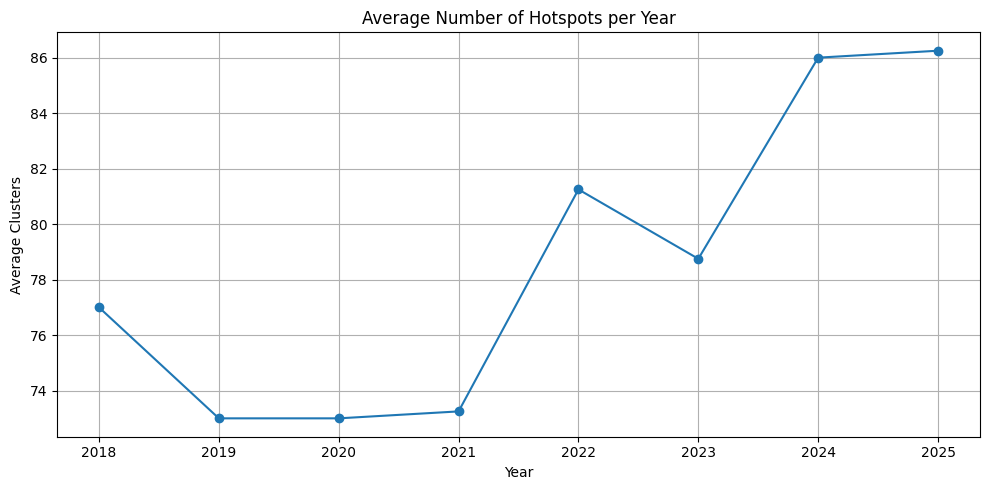

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_summary_df["Year"], yearly_summary_df["Avg_Clusters"], marker="o")
plt.title("Average Number of Hotspots per Year")
plt.xlabel("Year")
plt.ylabel("Average Clusters")
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "avg_hotspots_per_year.png"), dpi=300)
plt.show()

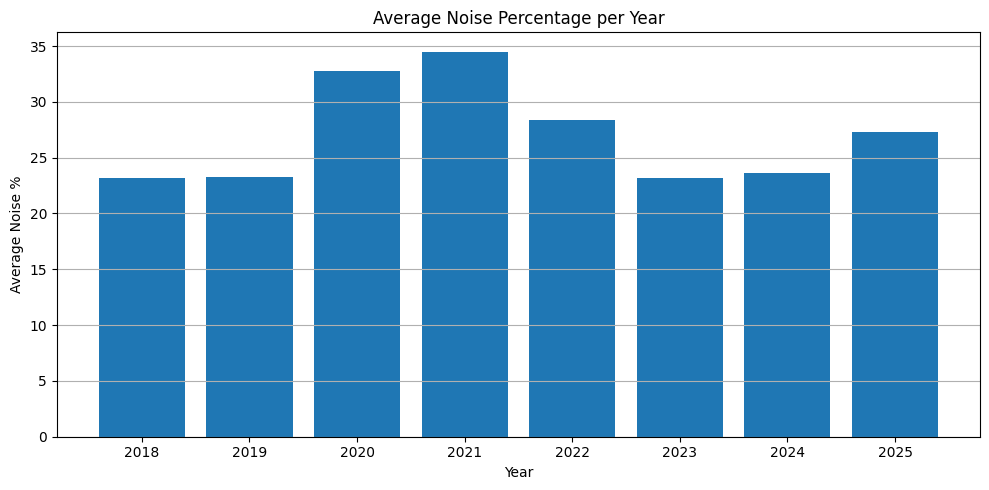

In [32]:
plt.figure(figsize=(10, 5))
plt.bar(yearly_summary_df["Year"], yearly_summary_df["Avg_Noise_Percentage"])
plt.title("Average Noise Percentage per Year")
plt.xlabel("Year")
plt.ylabel("Average Noise %")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "avg_noise_per_year.png"), dpi=300)
plt.show()

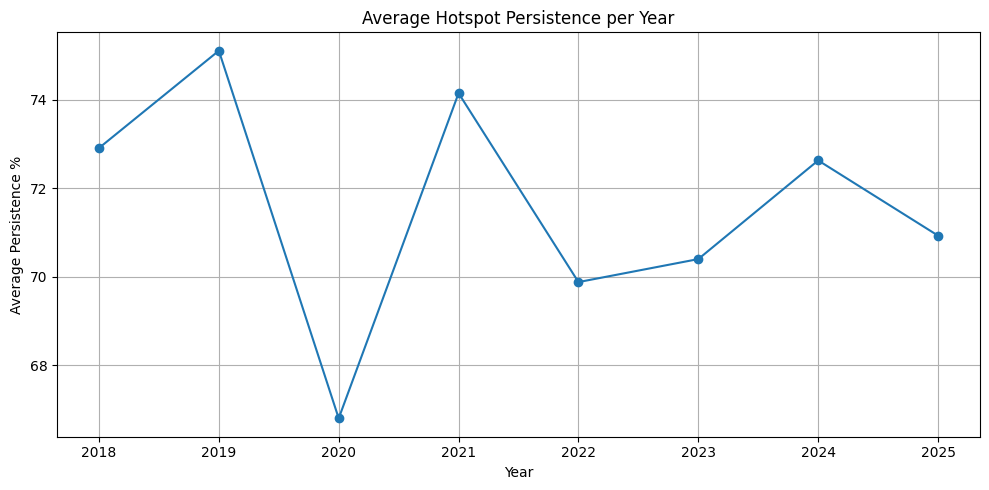

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_summary_df["Year"], yearly_summary_df["Avg_Persistence_Rate"], marker="o")
plt.title("Average Hotspot Persistence per Year")
plt.xlabel("Year")
plt.ylabel("Average Persistence %")
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "avg_persistence_per_year.png"), dpi=300)
plt.show()

In [34]:
print("\n========== FINAL YEARLY SUMMARY ==========")
print(yearly_summary_df.to_string(index=False))

best_persistence_year = yearly_summary_df.loc[yearly_summary_df["Avg_Persistence_Rate"].idxmax(), "Year"]
lowest_noise_year = yearly_summary_df.loc[yearly_summary_df["Avg_Noise_Percentage"].idxmin(), "Year"]
highest_hotspot_year = yearly_summary_df.loc[yearly_summary_df["Avg_Clusters"].idxmax(), "Year"]

print(f"\nYear with highest average persistence: {best_persistence_year}")
print(f"Year with lowest average noise: {lowest_noise_year}")
print(f"Year with highest average hotspots: {highest_hotspot_year}")


========== FINAL YEARLY SUMMARY ==========
 Year  Avg_Clusters  Avg_Noise_Percentage  Avg_Persistence_Rate
 2018         77.00                 23.22                 72.91
 2019         73.00                 23.24                 75.11
 2020         73.00                 32.74                 66.80
 2021         73.25                 34.50                 74.15
 2022         81.25                 28.35                 69.88
 2023         78.75                 23.18                 70.40
 2024         86.00                 23.60                 72.63
 2025         86.25                 27.27                 70.93

Year with highest average persistence: 2019
Year with lowest average noise: 2023
Year with highest average hotspots: 2025


In [35]:
quarter_counts = (
    df.groupby(["Year", "Quarter"])
      .size()
      .reset_index(name="Records")
      .sort_values(["Year", "Quarter"])
)

print(quarter_counts)

    Year Quarter  Records
0   2018  2018Q1    58434
1   2018  2018Q2    69304
2   2018  2018Q3    72361
3   2018  2018Q4    63424
4   2019  2019Q1    58161
5   2019  2019Q2    67926
6   2019  2019Q3    71230
7   2019  2019Q4    61853
8   2020  2020Q1    54199
9   2020  2020Q2    47431
10  2020  2020Q3    56472
11  2020  2020Q4    49867
12  2021  2021Q1    44392
13  2021  2021Q2    51041
14  2021  2021Q3    55724
15  2021  2021Q4    51714
16  2022  2022Q1    48159
17  2022  2022Q2    58089
18  2022  2022Q3    65654
19  2022  2022Q4    62982
20  2023  2023Q1    60071
21  2023  2023Q2    65486
22  2023  2023Q3    70703
23  2023  2023Q4    64983
24  2024  2024Q1    60243
25  2024  2024Q2    65677
26  2024  2024Q3    69906
27  2024  2024Q4    61732
28  2025  2025Q1    54656
29  2025  2025Q2    61091
30  2025  2025Q3    63985
31  2025  2025Q4    55606


In [36]:
yearly_records = (
    quarterly_summary_df
    .groupby("Year", as_index=False)
    .agg(Total_Records=("Records", "sum"))
)

yearly_summary_df["Hotspots_Per_10000_Records"] = (
    yearly_summary_df["Avg_Clusters"] / yearly_summary_df["Total_Records"] * 10000
).round(2)

yearly_summary_df = yearly_records.merge(yearly_summary_df, on="Year", how="left")
yearly_summary_df["Avg_Clustered_Percentage"] = (100 - yearly_summary_df["Avg_Noise_Percentage"]).round(2)

print(yearly_summary_df)

KeyError: 'Total_Records'